In [17]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [18]:
!pip install xclim xsdba

## Import Library

In [19]:
import datetime
import xesmf as xe
import xclim
from xclim import sdba
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import pearsonr

# Reproducibility
np.random.seed(42)

## Load Datasets

In [20]:
ds_forecast = xr.open_dataset("data/ifs_lowres_indonesia_2018-2022.zarr")
ds_truth = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

In [21]:
ds_forecast

<xarray.Dataset> Size: 5GB
Dimensions:                   (time: 3652, prediction_timedelta: 61,
                               longitude: 42, latitude: 33)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2018-01-01 ... 2022-...
  * prediction_timedelta      (prediction_timedelta) timedelta64[ns] 488B 00:...
  * longitude                 (longitude) float64 336B 88.5 90.0 ... 148.5 150.0
  * latitude                  (latitude) float64 264B -16.5 -15.0 ... 30.0 31.5
Data variables:
    10m_u_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    10m_v_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    2m_temperature            (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    total_precipitation_24hr  (time, prediction_timedelta, longitude, latitude) float32 1GB ...

In [22]:
ds_truth

<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 7304, latitude: 181, longitude: 201)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 724B 30.0 29.75 ... -15.0
  * longitude                 (longitude) float32 804B 90.0 90.25 ... 140.0
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 1GB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 1GB ...
    2m_temperature            (time, latitude, longitude) float32 1GB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 1GB ...

## Cropping data to this dimension
- Low-res shape  : 24 32
- High-res shape : 144 192

In [23]:
# =========================================
# Truth is the constraint — fit forecast to it
# =========================================
scale = 6

ds_truth    = ds_truth.sortby("latitude")     # ensure south → north
ds_forecast = ds_forecast.sortby("latitude")

tr_lons = ds_truth.longitude.values    # 90.0 → 140.0, 201 pts
tr_lats = ds_truth.latitude.values     # -15.0 → 30.0,  181 pts
fc_lats = ds_forecast.latitude.values  # -16.5 → 31.5
fc_lons = ds_forecast.longitude.values # 88.5  → 150.0

# ── Find forecast coords inside truth domain ──
valid_lons = fc_lons[(fc_lons >= tr_lons.min()) & (fc_lons <= tr_lons.max())]
valid_lats = fc_lats[(fc_lats >= tr_lats.min()) & (fc_lats <= tr_lats.max())]

lon_start = valid_lons[0]   # 90.0
lat_start = valid_lats[0]   # -15.0  ← south start, not 30.0

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))  # 0
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))  # 0

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx   # 201
avail_lat = len(tr_lats) - lat_start_idx   # 181

# ── Max forecast pts truth can support ──
max_fc_lon = avail_lon // scale   # 201 // 6 = 33
max_fc_lat = avail_lat // scale   # 181 // 6 = 30

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Crop forecast by index ──
fc_lon_start_idx = np.argmin(np.abs(fc_lons - lon_start))
fc_lat_start_idx = np.argmin(np.abs(fc_lats - lat_start))

ds_fc = ds_forecast.isel(
    longitude=slice(fc_lon_start_idx, fc_lon_start_idx + max_fc_lon),
    latitude =slice(fc_lat_start_idx, fc_lat_start_idx + max_fc_lat),
)
LOW_LON = len(ds_fc.longitude)
LOW_LAT = len(ds_fc.latitude)

# ── Slice truth by exact count ──
ds_tr = ds_truth.isel(
    longitude=slice(lon_start_idx, lon_start_idx + LOW_LON * scale),
    latitude =slice(lat_start_idx, lat_start_idx + LOW_LAT * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

print(f"\nForecast domain : lon {ds_fc.longitude.values[0]:.2f}→{ds_fc.longitude.values[-1]:.2f}"
      f"  lat {ds_fc.latitude.values[0]:.2f}→{ds_fc.latitude.values[-1]:.2f}")
print(f"Truth domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal forecast grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_fc.longitude.values, atol=1e-3)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_fc.latitude.values,  atol=1e-3)
print(f"Lons aligned        : {lon_ok}")
print(f"Lats aligned        : {lat_ok}")

if HIGH_LON == LOW_LON * scale and HIGH_LAT == LOW_LAT * scale and lon_ok and lat_ok:
    print(f"\n✅ Perfect {scale}× alignment!")
else:
    print(f"\n⚠ Still broken.")

lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Forecast domain : lon 90.00→136.50  lat -13.50→21.00
Truth domain    : lon 90.00→137.75  lat -13.50→22.25

Final forecast grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Lons aligned        : True
Lats aligned        : True

✅ Perfect 6× alignment!


In [24]:
ds_fc

<xarray.Dataset> Size: 3GB
Dimensions:                   (time: 3652, prediction_timedelta: 61,
                               longitude: 32, latitude: 24)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2018-01-01 ... 2022-...
  * prediction_timedelta      (prediction_timedelta) timedelta64[ns] 488B 00:...
  * longitude                 (longitude) float64 256B 90.0 91.5 ... 135.0 136.5
  * latitude                  (latitude) float64 192B -13.5 -12.0 ... 19.5 21.0
Data variables:
    10m_u_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 684MB ...
    10m_v_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 684MB ...
    2m_temperature            (time, prediction_timedelta, longitude, latitude) float32 684MB ...
    total_precipitation_24hr  (time, prediction_timedelta, longitude, latitude) float32 684MB ...

In [25]:
ds_tr

<xarray.Dataset> Size: 3GB
Dimensions:                   (time: 7304, latitude: 144, longitude: 192)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 576B -13.5 -13.25 ... 22.25
  * longitude                 (longitude) float32 768B 90.0 90.25 ... 137.8
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 808MB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 808MB ...
    2m_temperature            (time, latitude, longitude) float32 808MB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 808MB ...

## Check Missing Value

In [26]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:      46848 | 0.02738%
10m_v_component_of_wind        | NaNs:      46848 | 0.02738%
2m_temperature                 | NaNs:      46848 | 0.02738%
total_precipitation_24hr       | NaNs:   11262720 | 6.58296%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


In [27]:
def count_nan_per_time(ds, var):
    data = ds[var]

    spatial_dims = [d for d in data.dims if d != "time"]

    nan_count = data.isnull().sum(dim=spatial_dims)

    result = nan_count.to_dataframe(name="nan_count")
    result = result[result["nan_count"] > 0]

    print(result.head(20))

    return result

nan_summary = count_nan_per_time(ds_fc, "10m_u_component_of_wind")

# Get worst timestep (most NaNs)
worst_time = nan_summary["nan_count"].idxmax()

print("Worst timestep:", worst_time)

sample = ds_fc["10m_u_component_of_wind"].sel(time=worst_time)

print(sample)

            nan_count
time                 
2019-10-17      46848
Worst timestep: 2019-10-17 00:00:00
<xarray.DataArray '10m_u_component_of_wind' (prediction_timedelta: 61,
                                             longitude: 32, latitude: 24)> Size: 187kB
array([[[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       ...,

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]]], dtype=float32)
Coordinates:
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 488B 00:00:0..

#### Drop lead 0
because total precipitation in lead 0 is nan

In [28]:
ds_fc = ds_fc.sel(prediction_timedelta=slice(np.timedelta64(1,'D'), None))

In [29]:
check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:      43776 | 0.02738%
10m_v_component_of_wind        | NaNs:      43776 | 0.02738%
2m_temperature                 | NaNs:      43776 | 0.02738%
total_precipitation_24hr       | NaNs:      43776 | 0.02738%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


In [30]:
def check_fully_missing_timesteps(ds, name):
    print(f"\n==== Fully Missing Timesteps: {name} ====")
    for var in ds.data_vars:
        data = ds[var]
        # Collapse spatial dims
        spatial_dims = [d for d in data.dims if d != "time"]
        missing_time = data.isnull().all(dim=spatial_dims)
        n_missing = missing_time.sum().item()
        print(f"{var:30s} | fully-missing timesteps: {n_missing}")

check_fully_missing_timesteps(ds_fc, "Forecast")
check_fully_missing_timesteps(ds_tr, "Truth")


==== Fully Missing Timesteps: Forecast ====
10m_u_component_of_wind        | fully-missing timesteps: 1
10m_v_component_of_wind        | fully-missing timesteps: 1
2m_temperature                 | fully-missing timesteps: 1
total_precipitation_24hr       | fully-missing timesteps: 1

==== Fully Missing Timesteps: Truth ====
10m_u_component_of_wind        | fully-missing timesteps: 0
10m_v_component_of_wind        | fully-missing timesteps: 0
2m_temperature                 | fully-missing timesteps: 0
total_precipitation_24hr       | fully-missing timesteps: 0


In [31]:
def find_missing_timesteps(ds):
    for var in ds.data_vars:
        data = ds[var]
        spatial_dims = [d for d in data.dims if d != "time"]
        missing_time = data.isnull().all(dim=spatial_dims)

        missing_times = ds.time.where(missing_time, drop=True)

        print(f"\nVariable: {var}")
        print("Missing times:")
        print(missing_times.values)

find_missing_timesteps(ds_fc)


Variable: 10m_u_component_of_wind
Missing times:
['2019-10-17T00:00:00.000000000']

Variable: 10m_v_component_of_wind
Missing times:
['2019-10-17T00:00:00.000000000']

Variable: 2m_temperature
Missing times:
['2019-10-17T00:00:00.000000000']

Variable: total_precipitation_24hr
Missing times:
['2019-10-17T00:00:00.000000000']


In [32]:
# Auto-detect and drop ALL fully-missing timesteps (not hardcoded)
all_missing = set()
for var in ds_fc.data_vars:
    data = ds_fc[var]
    spatial_dims = [d for d in data.dims if d != "time"]
    missing_mask = data.isnull().all(dim=spatial_dims)
    missing_times = ds_fc.time.where(missing_mask, drop=True).values
    all_missing.update(missing_times)

all_missing = sorted(all_missing)
print(f"Dropping {len(all_missing)} fully-missing timesteps: {all_missing}")

if len(all_missing) > 0:
    ds_fc = ds_fc.drop_sel(time=all_missing)
    ds_tr = ds_tr.drop_sel(time=all_missing)

Dropping 1 fully-missing timesteps: [np.datetime64('2019-10-17T00:00:00.000000000')]


In [33]:
check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


## Temporal Allignment data

In [34]:
# ==============================
# CONFIG
# ==============================
lead_days = 1
lead_td = np.timedelta64(lead_days, "D")

# ==============================
# 1️⃣ Lead selection
# ==============================
ds_fc_lead = ds_fc.sel(prediction_timedelta=lead_td)

# ==============================
# 2️⃣ Compute valid time
# ==============================
valid_time = ds_fc_lead.time + lead_td

# ==============================
# 3️⃣ Find common times
# ==============================
common_times = np.intersect1d(valid_time.values,
                              ds_tr.time.values)

print("Common timesteps:", len(common_times))

# ==============================
# 4️⃣ Select only common times
# ==============================
ds_fc_lead = ds_fc_lead.assign_coords(valid_time=valid_time)
ds_fc_lead = ds_fc_lead.sel(valid_time=common_times)
ds_fc_lead = ds_fc_lead.assign_coords(time=ds_fc_lead.valid_time)
ds_fc_lead = ds_fc_lead.drop_vars("valid_time")

ds_tr_aligned = ds_tr.sel(time=common_times)

# ==============================
# 5️⃣ Final check
# ==============================
print("Forecast time == Truth time:",
      np.array_equal(ds_fc_lead.time.values,
                     ds_tr_aligned.time.values))

print("Forecast shape:",
      len(ds_fc_lead.time),
      len(ds_fc_lead.latitude),
      len(ds_fc_lead.longitude))

print("Truth shape:",
      len(ds_tr_aligned.time),
      len(ds_tr_aligned.latitude),
      len(ds_tr_aligned.longitude))

Common timesteps: 3648
Forecast time == Truth time: True
Forecast shape: 3648 24 32
Truth shape: 3648 144 192


## Quantile Mapping Downscaling with xclim

In [35]:
# ==========================================
# 1️⃣ Spatial Interpolation (Low-res to High-res)
# ==========================================
# Use bilinear interpolation with proper boundary handling
print("Interpolating forecast to high-res grid with bilinear (boundary-aware)...")

# Create regridder with bilinear method
# extrap_method='nearest_s2d' handles corners/edges by using nearest neighbor for out-of-bounds points
regridder = xe.Regridder(
    ds_fc_lead, 
    ds_tr_aligned, 
    method='bilinear',
    periodic=False,
    extrap_method='nearest_s2d',  # Use nearest neighbor extrapolation at corners/edges
    extrap_num_src_pnts=1,  # Number of source points for extrapolation
)

# Apply regridding to all variables
ds_fc_interp = regridder(ds_fc_lead)
print(f"  → Bilinear interpolation applied to all variables")
print(f"  → Corner/edge handling: nearest neighbor extrapolation")
print(f"Interpolated forecast shape: {ds_fc_interp.dims}")

# ==========================================
# 2️⃣ Train/Val/Test Split (temporal)
# ==========================================
VARS = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]

N = len(ds_fc_interp.time)
n_train = int(N * 0.7)
n_val   = int(N * 0.15)

# Split indices
train_slice = slice(0, n_train)
val_slice   = slice(n_train, n_train + n_val)
test_slice  = slice(n_train + n_val, None)

print(f"\nSplit sizes (N={N}):")
print(f"  Train : {n_train} ({n_train/N*100:.1f}%)")
print(f"  Val   : {n_val}   ({n_val/N*100:.1f}%)")
print(f"  Test  : {N - n_train - n_val}  ({(N - n_train - n_val)/N*100:.1f}%)")

# Create split datasets
fc_train = ds_fc_interp.isel(time=train_slice)
fc_val   = ds_fc_interp.isel(time=val_slice)
fc_test  = ds_fc_interp.isel(time=test_slice)

tr_train = ds_tr_aligned.isel(time=train_slice)
tr_val   = ds_tr_aligned.isel(time=val_slice)
tr_test  = ds_tr_aligned.isel(time=test_slice)

print("\nDatasets split successfully")

Interpolating forecast to high-res grid with bilinear (boundary-aware)...


/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


  → Bilinear interpolation applied to all variables
  → Corner/edge handling: nearest neighbor extrapolation
Interpolated forecast shape: FrozenMappingWarningOnValuesAccess({'time': 3648, 'latitude': 144, 'longitude': 192})

Split sizes (N=3648):
  Train : 2553 (70.0%)
  Val   : 547   (15.0%)
  Test  : 548  (15.0%)

Datasets split successfully


In [36]:
# ==========================================
# Add units metadata for xclim compatibility
# ==========================================
print("\nAdding units metadata...")

# Define units for each variable
units_dict = {
    "10m_u_component_of_wind": "m s-1",
    "10m_v_component_of_wind": "m s-1",
    "2m_temperature": "K",
    "total_precipitation_24hr": "mm",
}

# Add units to all split datasets
for var in VARS:
    fc_train[var].attrs['units'] = units_dict[var]
    fc_val[var].attrs['units'] = units_dict[var]
    fc_test[var].attrs['units'] = units_dict[var]
    
    tr_train[var].attrs['units'] = units_dict[var]
    tr_val[var].attrs['units'] = units_dict[var]
    tr_test[var].attrs['units'] = units_dict[var]
    
    print(f"  {var}: {units_dict[var]}")

print("✓ Units metadata added successfully")


Adding units metadata...
  10m_u_component_of_wind: m s-1
  10m_v_component_of_wind: m s-1
  2m_temperature: K
  total_precipitation_24hr: mm
✓ Units metadata added successfully


In [37]:
# ==========================================
# 3️⃣ Quantile Mapping Training
# ==========================================
print("\n" + "="*60)
print("Training Quantile Mapping models per variable...")
print("="*60)

# Dictionary to store trained QM models
qm_models = {}

for var in VARS:
    print(f"\n[{var}] Training Quantile Mapping...")
    
    # Get training data
    ref_train = tr_train[var]  # Reference (high-res truth)
    hist_train = fc_train[var]  # Historical (interpolated forecast)
    
    # Diagnostic: check unique value count
    ref_values = ref_train.values.flatten()
    hist_values = hist_train.values.flatten()
    ref_values = ref_values[~np.isnan(ref_values)]
    hist_values = hist_values[~np.isnan(hist_values)]
    
    n_unique_ref = len(np.unique(ref_values))
    n_unique_hist = len(np.unique(hist_values))
    print(f"  → Unique values: ref={n_unique_ref}, hist={n_unique_hist}")
    
    # Reduce nquantiles to avoid flat quantile regions
    # Use min of: 20, or half the unique values (safer)
    nquantiles = min(20, min(n_unique_ref, n_unique_hist) // 2)
    nquantiles = max(nquantiles, 5)  # at least 5 quantiles
    
    # For precipitation with many zeros, use even fewer quantiles
    if "precipitation" in var:
        nquantiles = min(10, nquantiles)  # max 10 quantiles for precipitation
        print(f"  → Using {nquantiles} quantiles (reduced for sparse precipitation)")
    else:
        print(f"  → Using {nquantiles} quantiles")
    
    # Use additive adjustment for all variables (more stable than multiplicative)
    print(f"  → Using EmpiricalQuantileMapping (additive adjustment)")
    QM = sdba.EmpiricalQuantileMapping.train(
        ref=ref_train,
        hist=hist_train,
        kind='+',  # additive adjustment - more stable for all variable types
        nquantiles=nquantiles,
    )
    
    qm_models[var] = QM
    print(f"  ✓ Trained with {len(ref_train.time)} timesteps")

print("\n" + "="*60)
print("✓ All Quantile Mapping models trained successfully")
print("="*60)


Training Quantile Mapping models per variable...

_u_component_of_wind] Training Quantile Mapping...
  → Unique values: ref=18552400, hist=44759929
  → Using 20 quantiles
  → Using EmpiricalQuantileMapping (additive adjustment)
  ✓ Trained with 2553 timesteps

_v_component_of_wind] Training Quantile Mapping...
  → Unique values: ref=16024352, hist=46161324
  → Using 20 quantiles
  → Using EmpiricalQuantileMapping (additive adjustment)
  ✓ Trained with 2553 timesteps

_temperature] Training Quantile Mapping...
  → Unique values: ref=808146, hist=661486
  → Using 20 quantiles
  → Using EmpiricalQuantileMapping (additive adjustment)
  ✓ Trained with 2553 timesteps

[total_precipitation_24hr] Training Quantile Mapping...
  → Unique values: ref=16097249, hist=42173097
  → Using 10 quantiles (reduced for sparse precipitation)
  → Using EmpiricalQuantileMapping (additive adjustment)
  ✓ Trained with 2553 timesteps

✓ All Quantile Mapping models trained successfully


In [38]:
# ==========================================
# 4️⃣ Apply Quantile Mapping to Validation Set
# ==========================================
print("\n" + "=" * 60)
print("Applying Quantile Mapping to validation set...")
print("=" * 60)

# Create a new dataset for corrected validation predictions
fc_val_corrected = fc_val.copy(deep=True)

for var in VARS:
    print(f"\n[{var}] Applying QM correction...")

    # Apply the trained QM model (use 'nearest' to avoid interpolation errors)
    corrected = qm_models[var].adjust(fc_val[var], interp="nearest")

    # Ensure corrected data uses the same dim order as fc_val[var]
    if tuple(corrected.dims) != tuple(fc_val[var].dims):
        corrected = corrected.transpose(*fc_val[var].dims)

    # ====== Safeguards against inf/nan ======
    # Get raw values as fallback
    raw_values = fc_val[var].values
    corrected_values = np.array(corrected.values, copy=True)

    # Defensive check for shape mismatch
    if corrected_values.shape != raw_values.shape:
        raise ValueError(
            f"Shape mismatch for {var}: corrected={corrected_values.shape}, raw={raw_values.shape}"
        )

    # Find invalid values (inf or nan)
    invalid_mask = ~np.isfinite(corrected_values)
    n_invalid = int(invalid_mask.sum())

    if n_invalid > 0:
        print(f"  ⚠ WARNING: {n_invalid} invalid values detected, using raw fallback")
        corrected_values = np.where(invalid_mask, raw_values, corrected_values)

    # For precipitation: clip to non-negative
    if "precipitation" in var:
        n_negative = int((corrected_values < 0).sum())
        if n_negative > 0:
            print(f"  ⚠ Clipping {n_negative} negative precipitation values to 0")
        corrected_values = np.maximum(corrected_values, 0.0)

    # Store cleaned values in corrected dataset
    corrected = corrected.copy(data=corrected_values)
    fc_val_corrected[var] = corrected

    print(f"  ✓ Corrected {len(fc_val.time)} timesteps")

print("\n" + "=" * 60)
print("✓ Validation set corrected successfully")
print("=" * 60)
    


Applying Quantile Mapping to validation set...

_u_component_of_wind] Applying QM correction...
  ✓ Corrected 547 timesteps

_v_component_of_wind] Applying QM correction...
  ✓ Corrected 547 timesteps

_temperature] Applying QM correction...
  ✓ Corrected 547 timesteps

[total_precipitation_24hr] Applying QM correction...
  ⚠ Clipping 932914 negative precipitation values to 0
  ✓ Corrected 547 timesteps

✓ Validation set corrected successfully


In [39]:
# ==========================================
# 5️⃣ Evaluation Metrics
# ==========================================
VAR_LABELS = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]

def compute_metrics_xarray(pred_ds, target_ds, var_names, var_labels):
    """
    Compute RMSE, MAE, Bias, Correlation, and ACC per variable.
    pred_ds, target_ds: xarray Datasets
    """
    metrics = {}
    
    for var, label in zip(var_names, var_labels):
        pred = pred_ds[var].values.flatten()
        target = target_ds[var].values.flatten()
        
        # Remove NaN pairs
        mask = ~(np.isnan(pred) | np.isnan(target))
        pred, target = pred[mask], target[mask]
        
        # RMSE
        rmse = np.sqrt(np.mean((pred - target) ** 2))
        
        # MAE
        mae = np.mean(np.abs(pred - target))
        
        # Bias
        bias = np.mean(pred - target)
        
        # Pearson Correlation
        if len(pred) > 1:
            corr = pearsonr(pred, target)[0]
        else:
            corr = 0.0
        
        # ACC — anomaly correlation
        pred_anom = pred - np.mean(pred)
        target_anom = target - np.mean(target)
        num = np.sum(pred_anom * target_anom)
        den = np.sqrt(np.sum(pred_anom ** 2) * np.sum(target_anom ** 2))
        acc = num / (den + 1e-8)
        
        metrics[label] = {
            "RMSE": rmse, "MAE": mae, "Bias": bias,
            "Corr": corr, "ACC": acc,
        }
    
    return metrics


def print_metrics(metrics, prefix=""):
    header = f"{'Variable':<18} {'RMSE':>8} {'MAE':>8} {'Bias':>8} {'Corr':>8} {'ACC':>8}"
    print(f"\n{prefix}")
    print(header)
    print("-" * len(header))
    for var, m in metrics.items():
        print(f"{var:<18} {m['RMSE']:>8.4f} {m['MAE']:>8.4f} {m['Bias']:>+8.4f} {m['Corr']:>8.4f} {m['ACC']:>8.4f}")

In [40]:
# ==========================================
# 6️⃣ Evaluate on Validation Set
# ==========================================
print("\n" + "="*60)
print("Validation Set Evaluation")
print("="*60)

# Compare raw interpolated vs QM-corrected vs truth
metrics_raw = compute_metrics_xarray(fc_val, tr_val, VARS, VAR_LABELS)
metrics_qm = compute_metrics_xarray(fc_val_corrected, tr_val, VARS, VAR_LABELS)

print_metrics(metrics_raw, prefix="📊 Validation - Raw Bilinear Interpolation")
print_metrics(metrics_qm, prefix="📊 Validation - Quantile Mapping Corrected")


Validation Set Evaluation

📊 Validation - Raw Bilinear Interpolation
Variable               RMSE      MAE     Bias     Corr      ACC
---------------------------------------------------------------
U10 (m/s)            1.2972   0.9681  -0.2869   0.9532   0.9532
V10 (m/s)            1.2159   0.9088  +0.0678   0.9348   0.9348
T2m (K)              1.0745   0.6985  -0.2369   0.8980   0.8980
TP 24hr (mm)         0.0068   0.0033  +0.0003   0.8093   0.8093

📊 Validation - Quantile Mapping Corrected
Variable               RMSE      MAE     Bias     Corr      ACC
---------------------------------------------------------------
U10 (m/s)            1.1274   0.8248  -0.0166   0.9627   0.9627
V10 (m/s)            1.1360   0.8373  -0.0623   0.9452   0.9452
T2m (K)              0.6546   0.4799  -0.1099   0.9625   0.9625
TP 24hr (mm)         0.0067   0.0031  -0.0001   0.8133   0.8135


In [41]:
# ==========================================
# 7️⃣ Apply Quantile Mapping to Test Set
# ==========================================
print("\n" + "="*60)
print("Applying Quantile Mapping to test set...")
print("="*60)

# Create a new dataset for corrected test predictions
fc_test_corrected = fc_test.copy(deep=True)

for var in VARS:
    print(f"\n[{var}] Applying QM correction to test set...")
    
    # Apply the trained QM model (use 'nearest' to avoid interpolation errors)
    corrected = qm_models[var].adjust(fc_test[var], interp='nearest')
    
    # Ensure corrected data uses the same dim order as fc_test[var]
    if tuple(corrected.dims) != tuple(fc_test[var].dims):
        corrected = corrected.transpose(*fc_test[var].dims)
    
    # ====== Safeguards against inf/nan ======
    # Get raw values as fallback
    raw_values = fc_test[var].values
    corrected_values = np.array(corrected.values, copy=True)
    
    # Defensive check for shape mismatch
    if corrected_values.shape != raw_values.shape:
        raise ValueError(
            f"Shape mismatch for {var}: corrected={corrected_values.shape}, raw={raw_values.shape}"
        )
    
    # Find invalid values (inf or nan)
    invalid_mask = ~np.isfinite(corrected_values)
    n_invalid = int(invalid_mask.sum())
    
    if n_invalid > 0:
        print(f"  ⚠ WARNING: {n_invalid} invalid values detected, using raw fallback")
        corrected_values = np.where(invalid_mask, raw_values, corrected_values)
    
    # For precipitation: clip to non-negative
    if "precipitation" in var:
        n_negative = int((corrected_values < 0).sum())
        if n_negative > 0:
            print(f"  ⚠ Clipping {n_negative} negative precipitation values to 0")
        corrected_values = np.maximum(corrected_values, 0.0)
    
    # Store cleaned values in corrected dataset
    corrected = corrected.copy(data=corrected_values)
    fc_test_corrected[var] = corrected
    
    print(f"  ✓ Corrected {len(fc_test.time)} timesteps")

print("\n" + "="*60)
print("✓ Test set corrected successfully")
print("="*60)


Applying Quantile Mapping to test set...

_u_component_of_wind] Applying QM correction to test set...
  ✓ Corrected 548 timesteps

_v_component_of_wind] Applying QM correction to test set...
  ✓ Corrected 548 timesteps

_temperature] Applying QM correction to test set...
  ✓ Corrected 548 timesteps

[total_precipitation_24hr] Applying QM correction to test set...
  ⚠ Clipping 750466 negative precipitation values to 0
  ✓ Corrected 548 timesteps

✓ Test set corrected successfully


In [42]:
# ==========================================
# 8️⃣ Test Set Evaluation
# ==========================================
print("\n" + "="*60)
print("Test Set Evaluation")
print("="*60)

# Compare raw interpolated vs QM-corrected vs truth
metrics_test_raw = compute_metrics_xarray(fc_test, tr_test, VARS, VAR_LABELS)
metrics_test_qm = compute_metrics_xarray(fc_test_corrected, tr_test, VARS, VAR_LABELS)

print_metrics(metrics_test_raw, prefix="📊 Test - Raw Bilinear Interpolation")
print_metrics(metrics_test_qm, prefix="📊 Test - Quantile Mapping Corrected")


Test Set Evaluation

📊 Test - Raw Bilinear Interpolation
Variable               RMSE      MAE     Bias     Corr      ACC
---------------------------------------------------------------
U10 (m/s)            1.2810   0.9557  -0.2450   0.9462   0.9462
V10 (m/s)            1.2150   0.9049  +0.1774   0.9233   0.9233
T2m (K)              1.0817   0.7120  -0.2457   0.8607   0.8607
TP 24hr (mm)         0.0068   0.0035  +0.0005   0.8059   0.8059

📊 Test - Quantile Mapping Corrected
Variable               RMSE      MAE     Bias     Corr      ACC
---------------------------------------------------------------
U10 (m/s)            1.1432   0.8384  +0.0221   0.9553   0.9553
V10 (m/s)            1.1417   0.8407  +0.0966   0.9345   0.9345
T2m (K)              0.6600   0.4883  -0.0969   0.9485   0.9485
TP 24hr (mm)         0.0067   0.0033  +0.0000   0.8098   0.8098


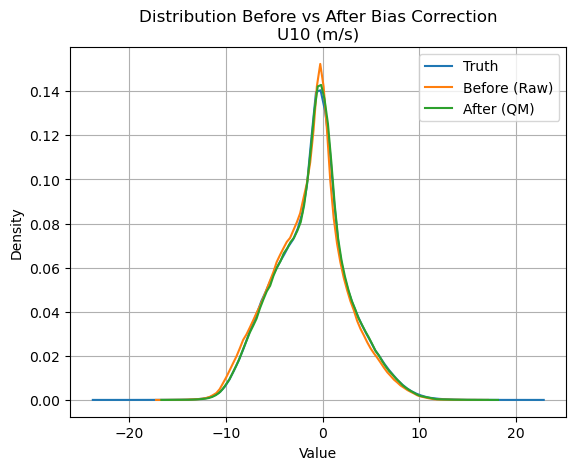

U10 (m/s)
Mean → Truth: -1.0816, Before: -1.3265, After: -1.0595
Std  → Truth: 3.8388, Before: 3.8255, After: 3.7981


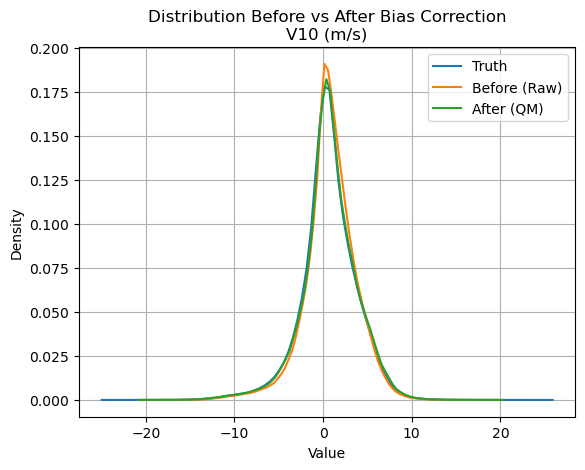

V10 (m/s)
Mean → Truth: 0.6228, Before: 0.8002, After: 0.7195
Std  → Truth: 3.1262, Before: 2.9428, After: 3.1570


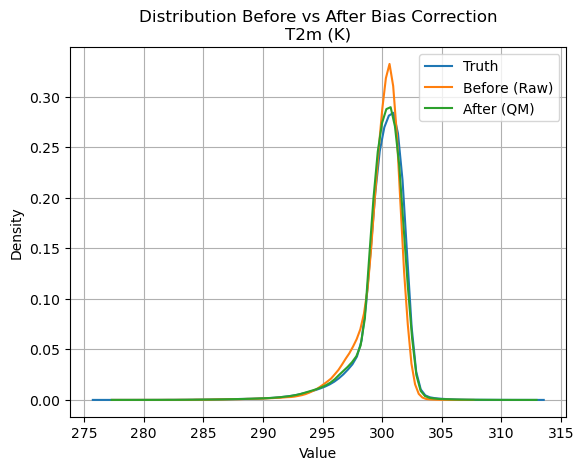

T2m (K)
Mean → Truth: 300.0353, Before: 299.7891, After: 299.9381
Std  → Truth: 2.0373, Before: 1.9376, After: 2.0301


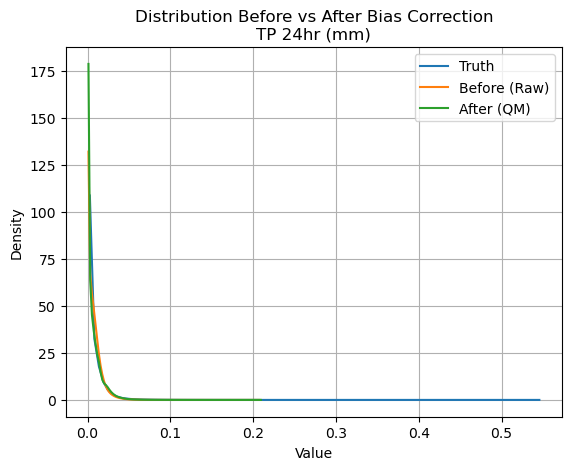

TP 24hr (mm)
Mean → Truth: 0.0075, Before: 0.0080, After: 0.0075
Std  → Truth: 0.0115, Before: 0.0087, After: 0.0096


In [43]:
def plot_bias_correction_distribution(pred_raw_ds, pred_qm_ds, truth_ds, var, label):
    # 🔴 ALIGN FIRST (CRITICAL)
    raw_da, truth_da = xr.align(pred_raw_ds[var], truth_ds[var], join="inner")
    qm_da, _ = xr.align(pred_qm_ds[var], truth_ds[var], join="inner")

    # Flatten AFTER alignment
    raw = raw_da.values.reshape(-1)
    qm  = qm_da.values.reshape(-1)
    truth = truth_da.values.reshape(-1)

    # Remove NaNs
    mask = ~np.isnan(raw) & ~np.isnan(qm) & ~np.isnan(truth)
    raw, qm, truth = raw[mask], qm[mask], truth[mask]

    # ==========================================
    # 1️⃣ PDF (LINE VERSION)
    # ==========================================
    plt.figure()

    def plot_pdf_line(data, label_name):
        hist, bins = np.histogram(data, bins=100, density=True)
        centers = 0.5 * (bins[1:] + bins[:-1])
        plt.plot(centers, hist, label=label_name)

    plot_pdf_line(truth, "Truth")
    plot_pdf_line(raw, "Before (Raw)")
    plot_pdf_line(qm, "After (QM)")

    plt.title(f"Distribution Before vs After Bias Correction\n{label}")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()

    plt.grid()
    plt.show()

    # ==========================================
    # 3️⃣ SUMMARY
    # ==========================================
    print(f"{label}")
    print(f"Mean → Truth: {truth.mean():.4f}, Before: {raw.mean():.4f}, After: {qm.mean():.4f}")
    print(f"Std  → Truth: {truth.std():.4f}, Before: {raw.std():.4f}, After: {qm.std():.4f}")

for var, label in zip(VARS, VAR_LABELS):
    plot_bias_correction_distribution(fc_test, fc_test_corrected, tr_test, var, label)

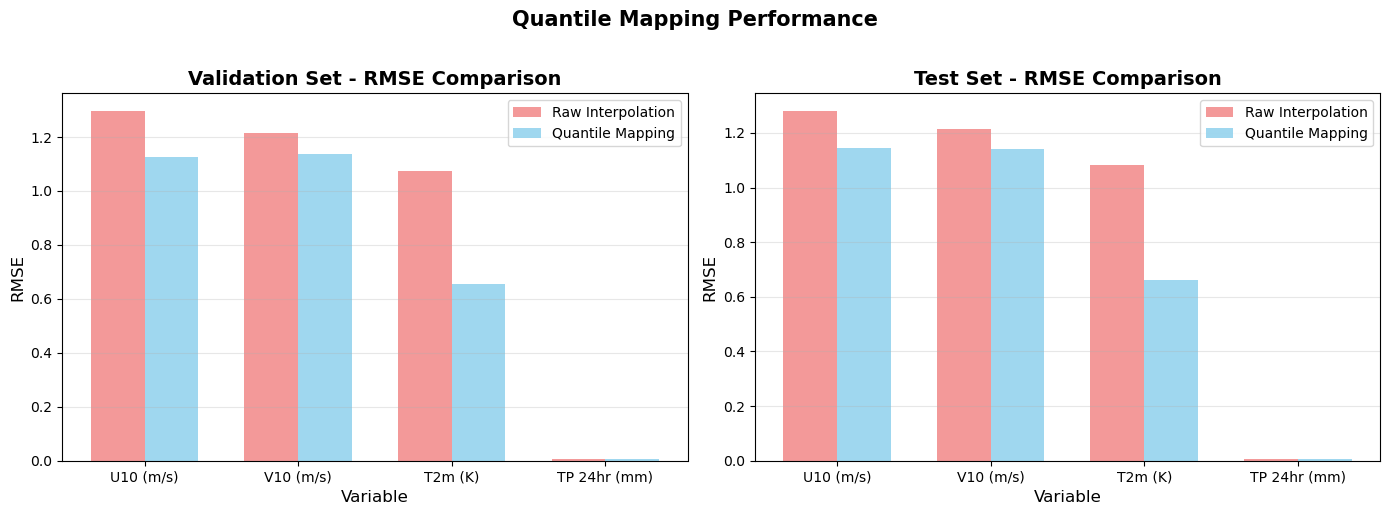


RMSE Improvement (% reduction)
U10 (m/s)          | Val: +13.09%  | Test: +10.76%
V10 (m/s)          | Val:  +6.57%  | Test:  +6.04%
T2m (K)            | Val: +39.08%  | Test: +38.99%
TP 24hr (mm)       | Val:  +1.38%  | Test:  +1.26%

Absolute RMSE Values
Variable           |    Val Raw |     Val QM |   Test Raw |    Test QM
------------------------------------------------------------
U10 (m/s)          |     1.2972 |     1.1274 |     1.2810 |     1.1432
V10 (m/s)          |     1.2159 |     1.1360 |     1.2150 |     1.1417
T2m (K)            |     1.0745 |     0.6546 |     1.0817 |     0.6600
TP 24hr (mm)       |     0.0068 |     0.0067 |     0.0068 |     0.0067


In [44]:
# ==========================================
# 9️⃣ Comparison Plot: RMSE Improvement
# ==========================================
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

var_colors = {
    VAR_LABELS[0]: "steelblue",
    VAR_LABELS[1]: "darkorange",
    VAR_LABELS[2]: "seagreen",
    VAR_LABELS[3]: "tomato",
}

# ── Left: Validation RMSE Comparison ──
val_raw_rmse = [metrics_raw[v]["RMSE"] for v in VAR_LABELS]
val_qm_rmse = [metrics_qm[v]["RMSE"] for v in VAR_LABELS]

x = np.arange(len(VAR_LABELS))
width = 0.35

ax1.bar(x - width/2, val_raw_rmse, width, label='Raw Interpolation', alpha=0.8, color='lightcoral')
ax1.bar(x + width/2, val_qm_rmse, width, label='Quantile Mapping', alpha=0.8, color='skyblue')

ax1.set_xlabel("Variable", fontsize=12)
ax1.set_ylabel("RMSE", fontsize=12)
ax1.set_title("Validation Set - RMSE Comparison", fontsize=14, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(VAR_LABELS, rotation=0, ha='center')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# ── Right: Test RMSE Comparison ──
test_raw_rmse = [metrics_test_raw[v]["RMSE"] for v in VAR_LABELS]
test_qm_rmse = [metrics_test_qm[v]["RMSE"] for v in VAR_LABELS]

ax2.bar(x - width/2, test_raw_rmse, width, label='Raw Interpolation', alpha=0.8, color='lightcoral')
ax2.bar(x + width/2, test_qm_rmse, width, label='Quantile Mapping', alpha=0.8, color='skyblue')

ax2.set_xlabel("Variable", fontsize=12)
ax2.set_ylabel("RMSE", fontsize=12)
ax2.set_title("Test Set - RMSE Comparison", fontsize=14, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(VAR_LABELS, rotation=0, ha='center')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle("Quantile Mapping Performance", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("qm_rmse_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Print improvement percentages (with safe division)
print("\n" + "="*60)
print("RMSE Improvement (% reduction)")
print("="*60)
for i, v in enumerate(VAR_LABELS):
    # Safe division - avoid inf
    if val_raw_rmse[i] > 1e-10:
        val_improv = (val_raw_rmse[i] - val_qm_rmse[i]) / val_raw_rmse[i] * 100
    else:
        val_improv = 0.0
    
    if test_raw_rmse[i] > 1e-10:
        test_improv = (test_raw_rmse[i] - test_qm_rmse[i]) / test_raw_rmse[i] * 100
    else:
        test_improv = 0.0
    
    print(f"{v:<18} | Val: {val_improv:+6.2f}%  | Test: {test_improv:+6.2f}%")

# Also print absolute RMSE values for debugging
print("\n" + "="*60)
print("Absolute RMSE Values")
print("="*60)
print(f"{'Variable':<18} | {'Val Raw':>10} | {'Val QM':>10} | {'Test Raw':>10} | {'Test QM':>10}")
print("-"*60)
for i, v in enumerate(VAR_LABELS):
    print(f"{v:<18} | {val_raw_rmse[i]:10.4f} | {val_qm_rmse[i]:10.4f} | {test_raw_rmse[i]:10.4f} | {test_qm_rmse[i]:10.4f}")

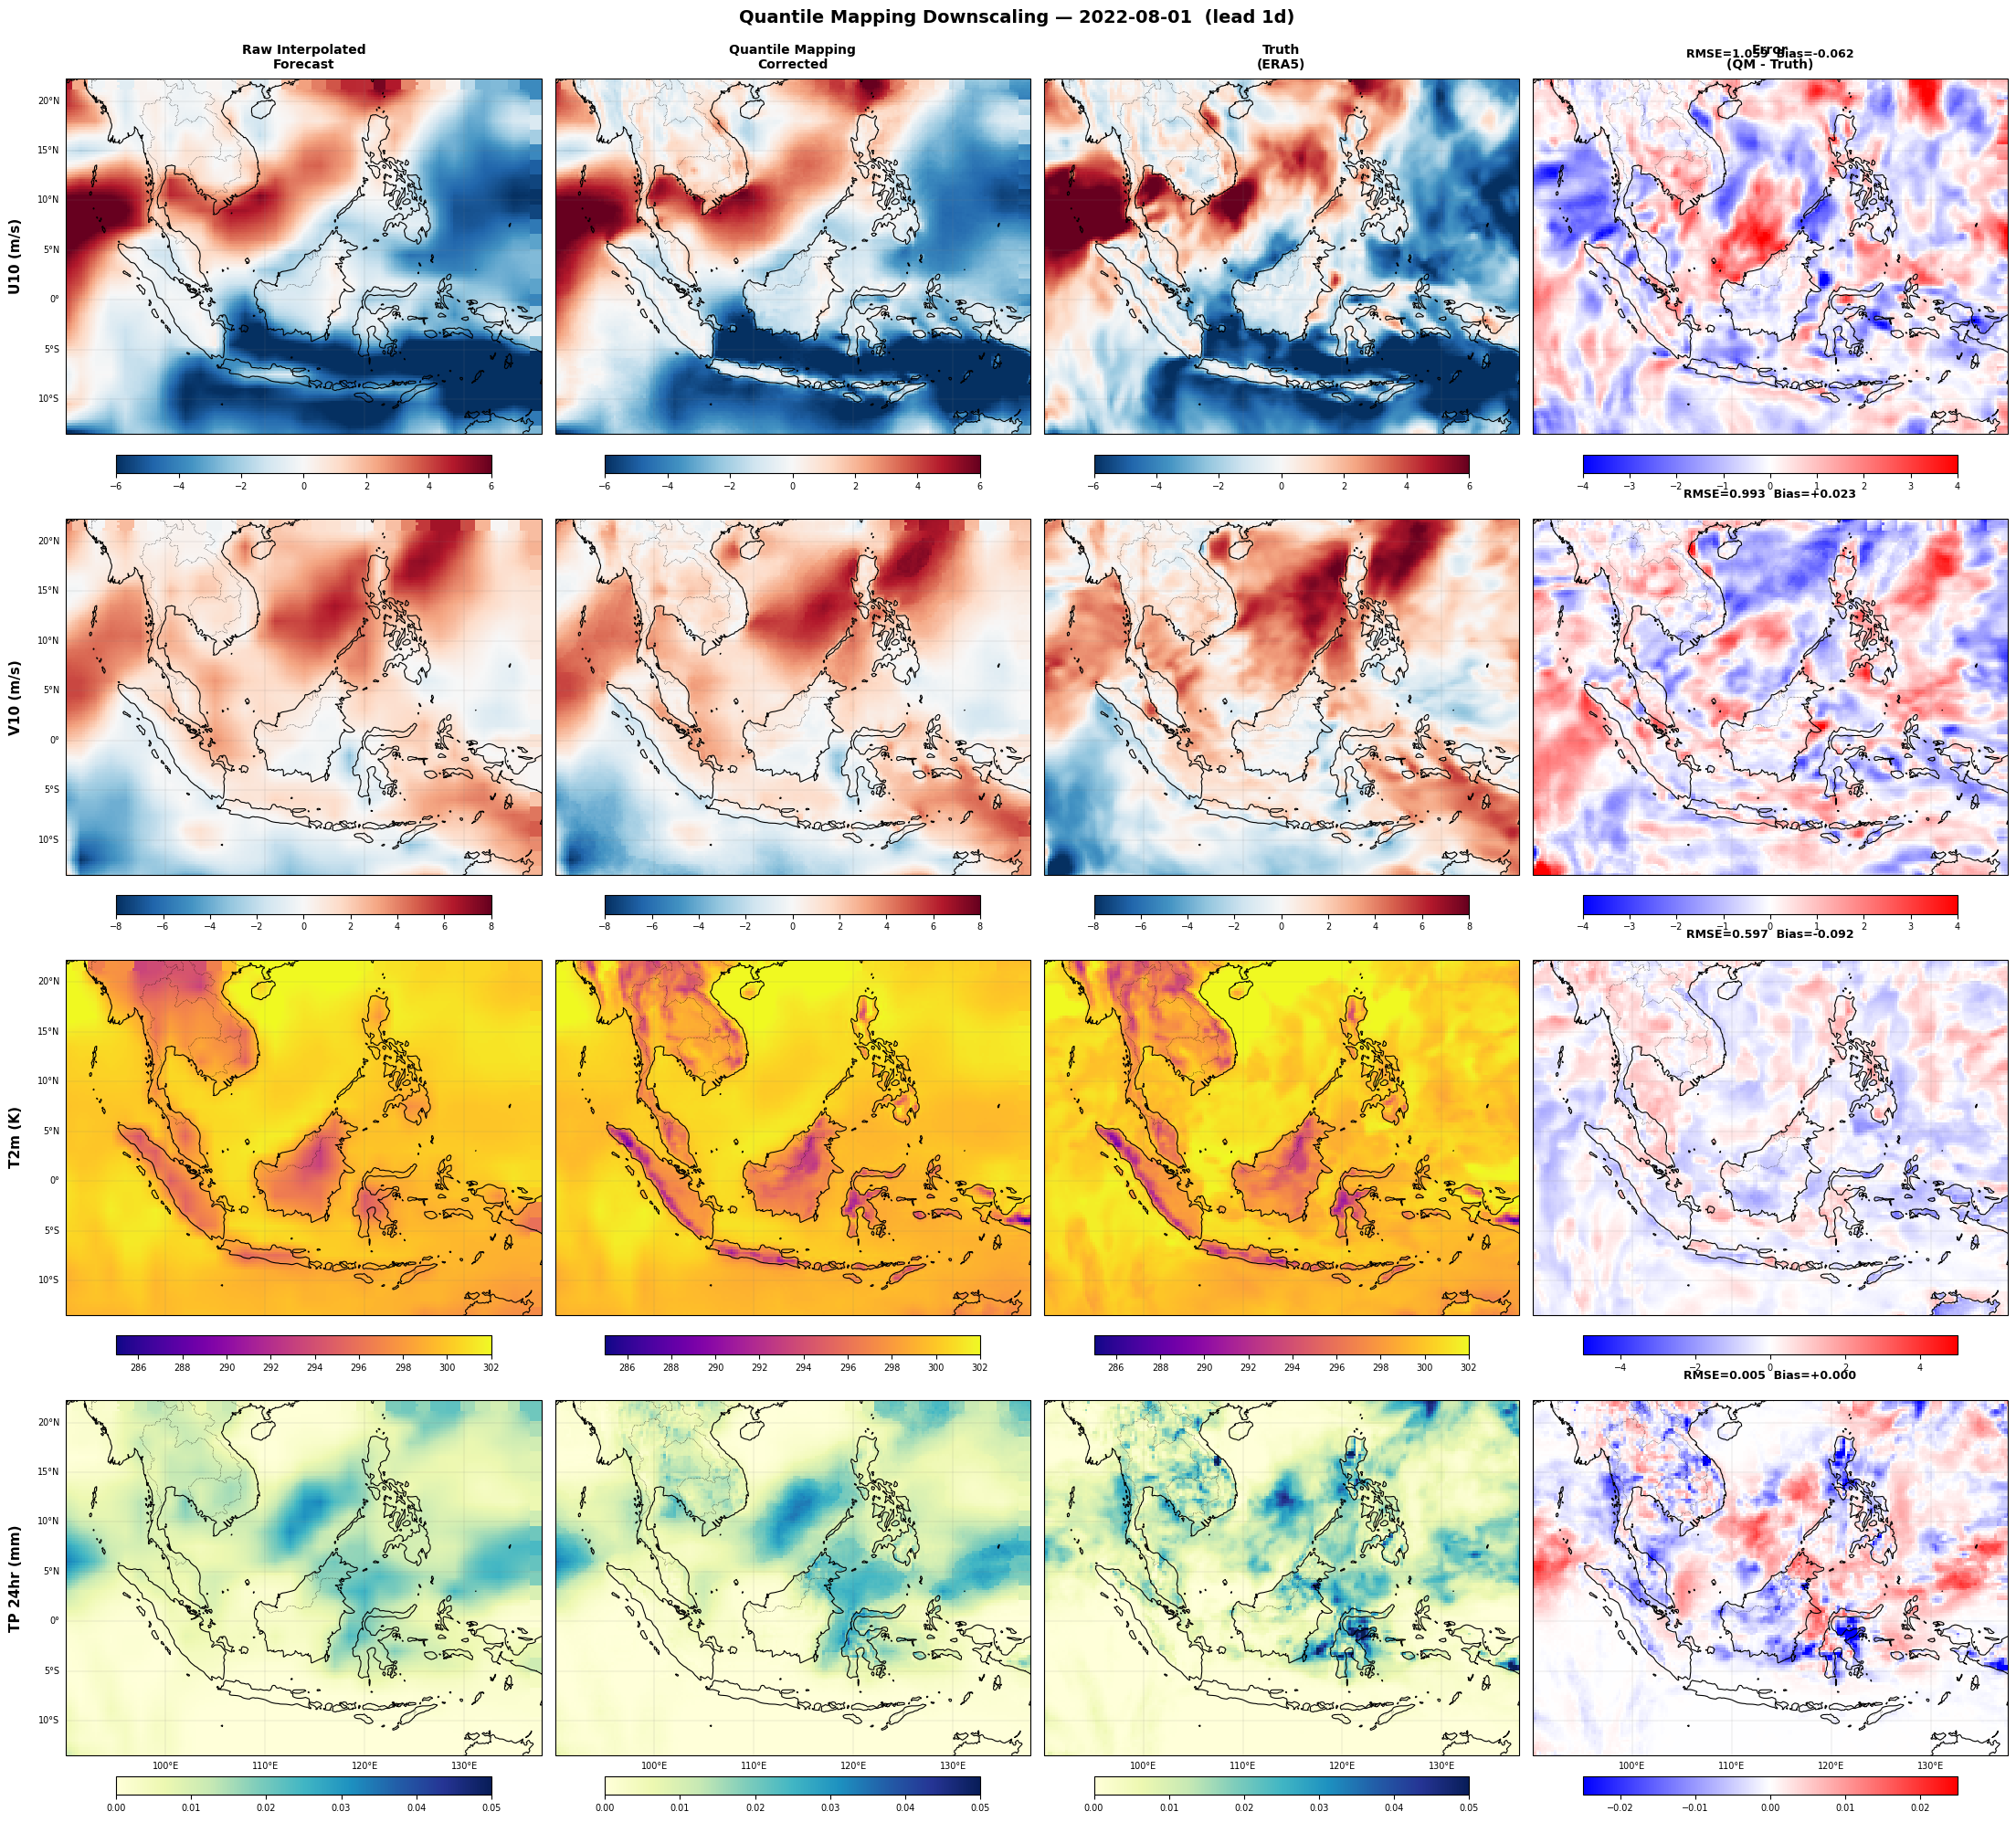

In [45]:
# ==========================================
# 🔟 Spatial Visualization - Sample Date
# ==========================================
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Config
VAR_LABELS_VIZ = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
target_date = np.datetime64("2022-08-01")

# Hardcoded color ranges (adjusted based on data)
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.050]  # Increased max for TP
ERROR_LIM  = [       4,     4,     5,   0.025]  # Increased for TP

# ==============================
# Find sample in test set
# ==============================
test_times = fc_test.time.values
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    print(f"⚠ {target_date} not found in test set.")
    print(f"Available range: {test_times[0]} → {test_times[-1]}")
    # Use first test sample instead
    idx = 0
    target_date = test_times[0]
    print(f"Using first test date: {target_date}")
else:
    idx = idx[0]

# Get sample data
fc_raw_sample = fc_test.isel(time=idx)
fc_qm_sample = fc_test_corrected.isel(time=idx)
truth_sample = tr_test.isel(time=idx)

# Get coordinates
lons_hr = truth_sample.longitude.values
lats_hr = truth_sample.latitude.values

# Set extent for all maps
extent = [lons_hr.min(), lons_hr.max(), lats_hr.min(), lats_hr.max()]

# ==============================
# Plot: 4 rows × 4 cols
# cols: Raw FC | QM Corrected | Truth | Error (QM - Truth)
# ==============================
proj = ccrs.PlateCarree()
n_vars = len(VARS)

col_titles = [
    "Raw Interpolated\nForecast",
    "Quantile Mapping\nCorrected",
    "Truth\n(ERA5)",
    "Error\n(QM - Truth)",
]

cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

fig, axes = plt.subplots(
    n_vars, 4,
    figsize=(22, 5 * n_vars),
    subplot_kw={"projection": proj},
)

# Helper function to ensure correct shape
def ensure_shape(data, target_shape):
    """Ensure data is in (lat, lon) shape"""
    if data.shape != target_shape:
        return data.T
    return data

target_shape = (len(lats_hr), len(lons_hr))

for v_idx, var in enumerate(VARS):
    # Get data (convert DataArray to numpy) and ensure consistent shape
    raw_v = ensure_shape(fc_raw_sample[var].values, target_shape)
    qm_v = ensure_shape(fc_qm_sample[var].values, target_shape)
    true_v = ensure_shape(truth_sample[var].values, target_shape)
    
    # Now compute error (shapes are guaranteed to match)
    err_v = qm_v - true_v
    
    cmap_f = cmaps_field[v_idx]
    
    # Hardcoded ranges
    vmin = FIELD_VMIN[v_idx]
    vmax = FIELD_VMAX[v_idx]
    elim = ERROR_LIM[v_idx]
    
    panels = [
        (raw_v,  cmap_f, vmin,  vmax),
        (qm_v,   cmap_f, vmin,  vmax),
        (true_v, cmap_f, vmin,  vmax),
        (err_v,  "bwr",  -elim,  elim),
    ]
    
    for col, (data, cmap, lo, hi) in enumerate(panels):
        ax = axes[v_idx, col]
        
        # Set extent to prevent padding issues
        ax.set_extent(extent, crs=proj)
        
        im = ax.pcolormesh(
            lons_hr, lats_hr, data,
            cmap=cmap, vmin=lo, vmax=hi,
            shading="nearest",
            transform=proj,
        )
        
        # Add features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":", zorder=2)
        ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0, alpha=0.3)
        ax.add_feature(cfeature.OCEAN, facecolor="lightcyan", zorder=0, alpha=0.3)
        
        # Gridlines with reduced clutter
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4,
                         x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 7}
        gl.ylabel_style = {"size": 7}
        
        # Only show labels on left and bottom edges
        if col > 0:
            gl.left_labels = False
        if v_idx < n_vars - 1:
            gl.bottom_labels = False
        
        # Colorbar
        cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046, shrink=0.9)
        cb.ax.tick_params(labelsize=7)
        
        # Titles
        if v_idx == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight="bold", pad=8)
        
        if col == 0:
            ax.text(-0.12, 0.5, VAR_LABELS_VIZ[v_idx], transform=ax.transAxes,
                    fontsize=11, fontweight="bold", va="center", rotation=90)
    
    # RMSE + bias on error panel
    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v_idx, 3].text(0.5, 1.06, f"RMSE={rmse:.3f}  Bias={bias:+.3f}",
                        transform=axes[v_idx, 3].transAxes,
                        ha='center', fontsize=9, fontweight='bold')

fig.suptitle(
    f"Quantile Mapping Downscaling — {str(target_date)[:10]}  (lead {lead_days}d)",
    fontsize=14, fontweight="bold", y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.savefig(f"qm_spatial_{str(target_date)[:10]}.png", dpi=150, bbox_inches="tight")
plt.show()

In [46]:
# ==========================================
# Diagnostic: Investigate QM Performance
# ==========================================
print("\n" + "="*70)
print("Diagnostic Analysis - Why is QM performing poorly on some variables?")
print("="*70)

for var, label in zip(VARS, VAR_LABELS):
    print(f"\n{'='*70}")
    print(f"Variable: {label}")
    print(f"{'='*70}")
    
    # Get test data
    pred_raw = fc_test[var].values.flatten()
    pred_qm = fc_test_corrected[var].values.flatten()
    truth = tr_test[var].values.flatten()
    
    # Remove NaNs
    mask = ~(np.isnan(pred_raw) | np.isnan(pred_qm) | np.isnan(truth))
    pred_raw = pred_raw[mask]
    pred_qm = pred_qm[mask]
    truth = truth[mask]
    
    # Statistics
    print(f"\nData range:")
    print(f"  Truth:      min={truth.min():.4f}, max={truth.max():.4f}, mean={truth.mean():.4f}, std={truth.std():.4f}")
    print(f"  Raw interp: min={pred_raw.min():.4f}, max={pred_raw.max():.4f}, mean={pred_raw.mean():.4f}, std={pred_raw.std():.4f}")
    print(f"  QM correc:  min={pred_qm.min():.4f}, max={pred_qm.max():.4f}, mean={pred_qm.mean():.4f}, std={pred_qm.std():.4f}")
    
    # Errors
    err_raw = pred_raw - truth
    err_qm = pred_qm - truth
    
    print(f"\nError statistics:")
    print(f"  Raw bias:  {err_raw.mean():+.4f}")
    print(f"  QM bias:   {err_qm.mean():+.4f}")
    print(f"  Raw RMSE:  {np.sqrt((err_raw**2).mean()):.4f}")
    print(f"  QM RMSE:   {np.sqrt((err_qm**2).mean()):.4f}")
    print(f"  Raw MAE:   {np.abs(err_raw).mean():.4f}")
    print(f"  QM MAE:    {np.abs(err_qm).mean():.4f}")
    
    # Check for extreme values
    extreme_qm = np.sum(np.abs(pred_qm) > 1e6)
    extreme_raw = np.sum(np.abs(pred_raw) > 1e6)
    if extreme_qm > 0 or extreme_raw > 0:
        print(f"\n⚠ WARNING: Extreme values detected!")
        print(f"  Raw: {extreme_raw} values > 1e6")
        print(f"  QM:  {extreme_qm} values > 1e6")

print("\n" + "="*70)


Diagnostic Analysis - Why is QM performing poorly on some variables?

Variable: U10 (m/s)

Data range:
  Truth:      min=-24.0173, max=23.1407, mean=-1.0816, std=3.8388
  Raw interp: min=-17.4108, max=17.2908, mean=-1.3265, std=3.8255
  QM correc:  min=-16.8620, max=18.3397, mean=-1.0595, std=3.7981

Error statistics:
  Raw bias:  -0.2450
  QM bias:   +0.0221
  Raw RMSE:  1.2810
  QM RMSE:   1.1432
  Raw MAE:   0.9557
  QM MAE:    0.8384

Variable: V10 (m/s)

Data range:
  Truth:      min=-25.2359, max=26.1467, mean=0.6228, std=3.1262
  Raw interp: min=-20.7028, max=19.7888, mean=0.8002, std=2.9428
  QM correc:  min=-21.0157, max=20.5098, mean=0.7195, std=3.1570

Error statistics:
  Raw bias:  +0.1774
  QM bias:   +0.0966
  Raw RMSE:  1.2150
  QM RMSE:   1.1417
  Raw MAE:   0.9049
  QM MAE:    0.8407

Variable: T2m (K)

Data range:
  Truth:      min=275.5442, max=313.7447, mean=300.0353, std=2.0373
  Raw interp: min=277.1960, max=307.8156, mean=299.7891, std=1.9376
  QM correc:  min=2

## Summary
Aggregate test-set evaluation showing per-variable RMSE, MAE, Bias, Correlation, and Skill Score.
**Baseline**: Raw bilinear interpolation (no correction).
**Method**: Quantile Mapping using xclim library.

In [47]:
import numpy as np
import xarray as xr

print("\n" + "="*100)
print(f"{'Variable':<18} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print("="*100)

for v_idx, var in enumerate(VARS):
    # Extract DataArrays
    da_pred = fc_test_corrected[var]
    da_true = tr_test[var]
    da_base = fc_test[var]
    
    # 1. Calculate Metrics per grid cell (along the 'time' dimension)
    # RMSE
    rmse_grid = np.sqrt(((da_pred - da_true) ** 2).mean(dim='time'))
    rmse_base_grid = np.sqrt(((da_base - da_true) ** 2).mean(dim='time'))
    
    # MAE & Bias
    mae_grid = (np.abs(da_pred - da_true)).mean(dim='time')
    bias_grid = (da_pred - da_true).mean(dim='time')
    
    # Correlation (using xarray's built-in correlation over time)
    corr_grid = xr.corr(da_pred, da_true, dim='time')
    
    # 2. Average the metrics spatially to get a single number per metric
    # .mean().values computes the global spatial average
    rmse = rmse_grid.mean().values
    rmse_base = rmse_base_grid.mean().values
    mae = mae_grid.mean().values
    bias = bias_grid.mean().values
    corr = corr_grid.mean().values
    
    # 3. Calculate Skill Score
    skill = 1.0 - (rmse / rmse_base) if rmse_base > 0 else 0.0
    
    label = VAR_LABELS[v_idx]
    print(f"{label:<18} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

print("="*100)


Variable           |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
U10 (m/s)          |   1.1060 |   0.8384 |  +0.0221 |   0.8721 |         1.2326 |  +0.1027
V10 (m/s)          |   1.1051 |   0.8407 |  +0.0966 |   0.8553 |         1.1738 |  +0.0585
T2m (K)            |   0.6243 |   0.4883 |  -0.0969 |   0.8288 |         0.8462 |  +0.2622
TP 24hr (mm)       |   0.0063 |   0.0033 |  +0.0000 |   0.8055 |         0.0064 |  +0.0088
